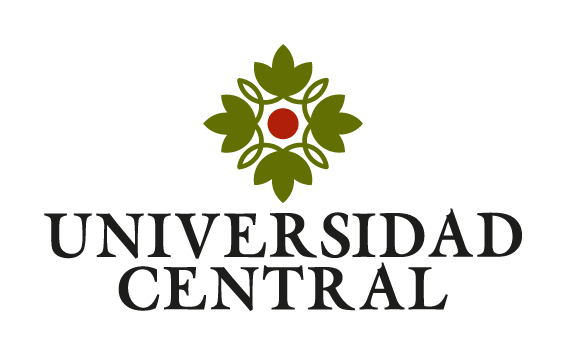

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 30 de 2026

Trabajo Final

# Etapa 1B · Generación de JSON limpios y clasificados — Autos de Apertura ANLA

Este notebook convierte los PDF de autos de inicio de procedimiento sancionatorio ambiental de la ANLA en un JSON estructurado, ya limpio y clasificado en una sola corrida, listo para la Etapa 2 (segmentación) y para los filtros del dashboard.

**Qué incorpora esta versión (antes eran scripts sueltos posteriores):**

- **IDs deterministas** (`id_documento`, `bloque.id`, `tabla.id`): se derivan del contenido identificador del auto, por lo que sobreviven a reindexados. Esto evita que un gold set etiquetado quede huérfano si se vuelve a correr la Etapa 2.
- **Extracción robusta** de `empresa`, `nit_investigado`, `proyecto` y `municipios`, anclada al texto canónico del auto (Resuelve + Antecedentes). Tolera el sufijo `E.S.P.`, guiones, comillas tipográficas y `NIT` sin dos puntos.
- **NIT del investigado** (excluye explícitamente el NIT de la ANLA del pie de página, `900.467.239-2`, que de otro modo contamina la extracción).
- **Empresa normalizada** a forma canónica → el dashboard agrupa bien.
- **`municipio`** (principal, para mostrar) **+ `municipios`** (lista completa, para filtrar). Los autos de líneas de flujo cruzan muchos municipios.
- Campo nuevo **`materias`** (+ `materias_score`) por reglas auditables → habilita la consulta jurimétrica "tráeme los autos por contingencias".

> Reutilizable: para procesar un lote nuevo, basta con apuntar `INPUT_DIR`/`OUTPUT_DIR` y ejecutar todo. El notebook **salta** los PDF ya convertidos.

# HOJA DE RUTA

0. Montar Google Drive
1. Instalar dependencias del sistema
2. Instalar librerías e imports
3. Configuración de rutas
4. Diccionarios y modelos de datos (Pydantic)
5. Funciones auxiliares: extractores robustos · clasificador de materia · IDs deterministas
6. Pipeline unificado de segmentación y limpieza
7. Procesamiento batch
8. Diagnóstico: PDFs dentrada vs JSON de salida
8. Validación de cobertura de campos
9. Inspección de un documento
10. Distribución de materias para el análisis jurimétrico

# 0. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Instalar dependencias del sistema

In [ ]:
!apt-get -qq install -y poppler-utils tesseract-ocr tesseract-ocr-spa > /dev/null
!pip install -q 'unstructured[pdf]' pandas pydantic lxml html5lib beautifulsoup4 pdfminer.six tabulate tqdm pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 624.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.1/543.1 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 29.6 MB/s eta 0:00:0

# 2. Instalar librerías e imports

In [ ]:
import os
import json
import re
import time
import hashlib
import unicodedata
import warnings
from io import StringIO
from datetime import datetime
from collections import Counter, defaultdict
from typing import List, Optional, Dict, Tuple
from pathlib import Path

import pandas as pd
import pdfplumber
from pydantic import BaseModel, Field
from unstructured.partition.pdf import partition_pdf
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)
print('✅ Imports OK')

✅ Imports OK


# 3. Configuración de rutas

Ajusta `INPUT_DIR` (carpeta con los PDF) y `OUTPUT_DIR` (carpeta de JSON). Para reprocesar **todo** desde cero, pon `SOBREESCRIBIR = True` (ignora los JSON ya existentes). Por defecto el notebook **salta** los que ya estén convertidos.

In [ ]:
INPUT_DIR  = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Actos_Apertura_pdf/pdf_debug_5'
OUTPUT_DIR = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs'

SOBREESCRIBIR = True   # True = reprocesa aunque el JSON ya exista

if not os.path.exists(INPUT_DIR):
    raise FileNotFoundError(f'❌ No existe INPUT_DIR: {INPUT_DIR}')
os.makedirs(OUTPUT_DIR, exist_ok=True)

archivos = sorted(f for f in os.listdir(INPUT_DIR) if f.lower().endswith('.pdf'))
print(f'📂 Entrada : {INPUT_DIR}')
print(f'📂 Salida  : {OUTPUT_DIR}')
print(f'📄 PDFs    : {len(archivos)}')
print(f'♻️  Sobreescribir: {SOBREESCRIBIR}')

📂 Entrada : /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Actos_Apertura_pdf/pdf_debug_5
📂 Salida  : /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs
📄 PDFs    : 6
♻️  Sobreescribir: True


# 4. Diccionarios y modelos de datos (Pydantic)

Los modelos incorporan los campos nuevos: `fecha_ordinal`, `municipios` (lista), `materias` y `materias_score`.

In [ ]:
# Modelos Pydantic
class ElementoTabular(BaseModel):
    id: str
    seccion: Optional[str] = None
    titulo: Optional[str] = None
    markdown: str
    fuente: str  # 'html' | 'texto_plano' | 'pdfplumber' | 'preformateado'
    dimensiones: Dict[str, int] = Field(default_factory=dict)
    pagina: Optional[int] = None


class Bloque(BaseModel):
    id: str
    numeral: Optional[str] = None
    tipo_numeral: Optional[str] = None
    nivel: int = 0
    titulo: Optional[str] = None
    texto: str = ''
    pagina_inicio: Optional[int] = None
    pagina_fin: Optional[int] = None
    tablas_anidadas: List[ElementoTabular] = Field(default_factory=list)


class Documento(BaseModel):
    id_documento: str
    filename: str
    tipo_documento: Optional[str] = None
    numero_documento: Optional[str] = None
    fecha_documento: Optional[str] = None
    fecha_ordinal: Optional[int] = None
    expediente_sancionatorio: Optional[str] = None
    expediente_permisivo: Optional[str] = None
    empresa: Optional[str] = None
    nit_investigado: Optional[str] = None
    proyecto: Optional[str] = None
    municipio: Optional[str] = None
    municipios: Optional[List[str]] = None
    ubicacion: Optional[str] = None
    materias: List[str] = Field(default_factory=list)
    materias_score: Dict[str, int] = Field(default_factory=dict)
    bloques: List[Bloque] = Field(default_factory=list)
    tablas: List[ElementoTabular] = Field(default_factory=list)
    metadata: Dict = Field(default_factory=dict)


MESES = {
    'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
    'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
    'septiembre': '09', 'setiembre': '09', 'octubre': '10',
    'noviembre': '11', 'diciembre': '12',
}
MESES_ABREV = {
    'ENE': '01', 'FEB': '02', 'MAR': '03', 'ABR': '04', 'MAY': '05', 'JUN': '06',
    'JUL': '07', 'AGO': '08', 'SEP': '09', 'OCT': '10', 'NOV': '11', 'DIC': '12',
}

print('✅ Modelos cargados (con fecha_ordinal, municipios, materias, materias_score)')

✅ Modelos cargados (con fecha_ordinal, municipios, materias, materias_score)


# 5. Funciones auxiliares

Extractores robustos (NIT/empresa/proyecto/municipios), clasificador de materia por reglas e IDs deterministas. **Se debe `EMPRESAS_CANONICAS`** cuando aparezca una empresa nueva, y **`MATERIAS`** por si es necesario afinar el vocabulario temático de tu corpus.

In [ ]:

import hashlib
import unicodedata

# ── NIT de la ANLA (pie de página). NUNCA es el investigado. ──
NIT_ANLA = "900.467.239-2"

# ── Normalización de empresa → forma canónica ──
#    clave = subcadena a buscar (minúscula); valor = nombre canónico a fijar.
EMPRESAS_CANONICAS = {
    "transportadora de gas internacional": "TRANSPORTADORA DE GAS INTERNACIONAL S.A. E.S.P. (TGI)",
    "gran tierra energy":                  "GRAN TIERRA ENERGY COLOMBIA LLC",
    "ecopetrol":                           "ECOPETROL S.A.",
    "hocol":                               "HOCOL S.A.",
    "parex":                               "PAREX RESOURCES COLOMBIA",
    "frontera energy":                     "FRONTERA ENERGY COLOMBIA",
    "geopark":                             "GEOPARK COLOMBIA",
    "cenit":                               "CENIT TRANSPORTE Y LOGISTICA DE HIDROCARBUROS S.A.S.",
    "oleoducto central":                   "OLEODUCTO CENTRAL S.A. (OCENSA)",
    "ocensa":                              "OLEODUCTO CENTRAL S.A. (OCENSA)",
    "perenco":                             "PERENCO COLOMBIA LTD",
    "petroleos sudamericanos":             "PETROLEOS SUDAMERICANOS ENERGY SUCURSAL COLOMBIA",
    "mansarovar":                          "MANSAROVAR ENERGY COLOMBIA LTD",
    "tpl":                                 "TPL COLOMBIA LTD",
    "cenit":                               "CENIT TRANSPORTE Y LOGÍSTICA DE HIDROCARBUROS S.A.S",
    "comtrol":                              "COMTROL COLOMBIA S.A"


}

# ── Diccionario de MATERIAS (reglas, sin tildes y en minúscula). ──
#    Editable y auditable. Añade/quita términos según veas tu corpus.
MATERIAS = {
    "contingencias_ambientales": [
        r"\bcontingencia", r"\bvital\b", r"\bfuga de gas", r"\bderrame",
        r"reconformacion del area", r"reporte de contingencias",
        r"resolucion\s*1767", r"formato unico", r"\bfuc\b", r"venteo",
    ],
    "evaluacion_economica_ambiental": [
        r"valoracion economica", r"evaluacion economica", r"flujo de costos",
        r"flujo economico", r"\bvpn\b", r"\brcb\b", r"valor presente neto",
        r"relacion costo beneficio", r"indicadores economicos",
        r"analisis de sensibilidad", r"costo de oportunidad",
    ],
    "gestion_del_riesgo": [
        r"plan de contingencia", r"gestion del riesgo", r"decreto\s*2157",
        r"movimientos en masa", r"reduccion del riesgo", r"plan de gestion del riesgo",
        r"caracterizacion de amenazas", r"socavacion", r"puntos criticos",
    ],
    "participacion_comunitaria": [
        r"simulacro", r"participacion comunitaria", r"socializacion",
        r"informacion y participacion", r"junta de accion comunal", r"\bjac\b",
        r"reuniones? con la comunidad", r"pautas de convivencia",
    ],
    "obligaciones_seguimiento_ica": [
        r"informe de cumplimiento ambiental", r"\bica\b", r"radicado anla",
        r"requerimiento", r"plan de manejo ambiental", r"\bpma\b",
        r"obligaciones establecidas",
    ],
    "compensacion_inversion": [
        r"inversion del 1", r"compensacion forestal", r"medida de compensacion",
        r"restauracion", r"revegetalizacion",
    ],
}
UMBRAL_MATERIA = 1  # nº mínimo de coincidencias para asignar una materia


def normalizar(texto: str) -> str:
    """Minúscula + sin tildes (para que las reglas peguen sin importar acentos)."""
    if not texto:
        return ""
    t = texto.lower()
    t = unicodedata.normalize("NFKD", t)
    return "".join(ch for ch in t if not unicodedata.combining(ch))


# ─────────────────────── IDs DETERMINISTAS ───────────────────────
def id_documento_determinista(filename: str, tipo: Optional[str],
                              numero: Optional[str], fecha: Optional[str]) -> str:
    """
    ID estable derivado del contenido identificador del auto.
    Si hay tipo+numero+fecha → 'AUTO_001516_2024-03-20'.
    Si no, hash corto del filename (estable entre corridas).
    """
    if tipo and numero:
        f = (fecha or "").strip()
        base = f"{tipo}_{int(numero):06d}" if numero.isdigit() else f"{tipo}_{numero}"
        return f"{base}_{f}" if f else base
    h = hashlib.sha1(filename.encode("utf-8")).hexdigest()[:12]
    return f"DOC_{h}"


# ─────────────────────── EXTRACTORES (texto canónico) ───────────────────────
def _norm_nit(s: str) -> str:
    d = re.sub(r"[^\d]", "", s)
    return f"{d[0:3]}.{d[3:6]}.{d[6:9]}-{d[9]}" if len(d) == 10 else s.strip()


def extraer_nit(t: str) -> Optional[str]:
    # 1) Preferir el NIT ligado al investigado en el Resuelve
    m = re.search(r"(?:con\s+(?:el\s+)?NIT|identificada\s+con\s+(?:el\s+)?NIT)"
                  r"[\s.:]*(?:N[°ºo.]*\s*)?(\d{3}\.?\d{3}\.?\d{3}\s*-?\s*\d)",
                  t, re.IGNORECASE)
    if m:
        return _norm_nit(m.group(1))
    # 2) Cualquier NIT que NO sea el de la ANLA
    todos = [_norm_nit(n) for n in re.findall(
        r"NIT[\s.:]*(?:N[°ºo.]*\s*)?(\d{3}\.?\d{3}\.?\d{3}\s*-?\s*\d)", t, re.IGNORECASE)]
    cand = [n for n in todos if n != NIT_ANLA]
    return Counter(cand).most_common(1)[0][0] if cand else None


def _canonizar_empresa(nombre: str) -> str:
    bajo = nombre.lower()
    for clave, canonico in EMPRESAS_CANONICAS.items():
        if clave in bajo:
            return canonico
    return re.sub(r"\s+", " ", nombre).strip().rstrip(".,")


def extraer_empresa(t: str) -> Optional[str]:
    pats = [
        r"(?:contra|inicio[^.]{0,40}?contra)\s+(?:de\s+)?la\s+[Ss]ociedad\s+(.+?)(?:,?\s+(?:con|identificada))",
        r"[Ss]ociedad\s+([A-ZÁÉÍÓÚÑ][\w\sÁÉÍÓÚÑáéíóúñ.\-&]+?\s+"
        r"(?:S\.?A\.?S?\.?|LTD|LLC)\.?\s*(?:E\.?S\.?P\.?)?(?:\s+SUCURSAL)?)",
    ]
    cand = []
    for p in pats:
        cand += [re.sub(r"\s+", " ", m).strip().rstrip(".,") for m in re.findall(p, t)]
    cand = [c for c in cand if 5 < len(c) < 90]
    if not cand:
        return None
    crudo = Counter(cand).most_common(1)[0][0]
    return _canonizar_empresa(crudo)


def extraer_proyecto(t: str) -> Optional[str]:
    """Devuelve el proyecto MÁS MENCIONADO (el principal del auto), no el primero
    que aparezca (que suele ser un antecedente). Tolera comillas tipográficas."""
    cands = re.findall(
        r'proyecto\s+(?:denominado\s+)?[«"\u201c\u201d\'\u2018\u2019]'
        r'(.{5,120}?)[»"\u201c\u201d\'\u2018\u2019]', t, re.IGNORECASE)
    cands = [re.sub(r"\s+", " ", c).strip() for c in cands]
    cands = [c for c in cands if len(c) > 4]
    if not cands:
        return None
    return Counter(cands).most_common(1)[0][0]


_MUNI_RUIDO = {"La", "El", "Los", "Las", "De", "Del", "En"}


def extraer_municipios(t: str) -> Tuple[Optional[str], List[str]]:
    """
    Devuelve (municipio_principal, lista_municipios).
    Los autos de gasoducto cruzan muchos municipios: guardamos el más
    mencionado como principal y la lista completa para filtrar en el dashboard.
    """
    pat = re.compile(
        r"municipio[s]?\s+de\s+"
        r"([A-ZÁÉÍÓÚÑ][A-Za-záéíóúñÁÉÍÓÚÑ]+(?:\s+[A-ZÁÉÍÓÚÑ][A-Za-záéíóúñ]+){0,2})")
    encontrados = [re.sub(r"\s+", " ", m).strip() for m in pat.findall(t)]
    encontrados = [m for m in encontrados if m not in _MUNI_RUIDO and len(m) > 2]
    if not encontrados:
        return None, []
    cont = Counter(encontrados)
    principal = cont.most_common(1)[0][0]
    lista = [m for m, _ in cont.most_common()][:10]
    return principal, lista


# ─────────────────────── CLASIFICADOR DE MATERIA ───────────────────────
def _texto_completo_bloques(bloques) -> str:
    """Concatena título + texto de todos los bloques (y títulos de tablas)."""
    partes = []
    for b in bloques:
        partes.append(getattr(b, "titulo", "") or "")
        partes.append(getattr(b, "texto", "") or "")
        for tb in (getattr(b, "tablas_anidadas", None) or []):
            partes.append(getattr(tb, "titulo", "") or "")
    return normalizar(" ".join(partes))


def clasificar_materias(bloques) -> Tuple[List[str], Dict[str, int]]:
    """Devuelve (materias:list, scores:dict) a partir de los bloques del documento."""
    blob = _texto_completo_bloques(bloques)
    scores = {}
    for materia, patrones in MATERIAS.items():
        n = sum(len(re.findall(p, blob)) for p in patrones)
        if n > 0:
            scores[materia] = n
    materias = sorted([m for m, n in scores.items() if n >= UMBRAL_MATERIA],
                      key=lambda m: scores[m], reverse=True)
    return materias, scores


print("✅ Extractores robustos, clasificador de materia e IDs deterministas cargados")

✅ Extractores robustos, clasificador de materia e IDs deterministas cargados


# 6. Pipeline Unificado de Segmentación y Limpieza

In [ ]:
class ANLAPipelineV5:
    """
    Pipeline unificado Etapa 1B (v5) para Autos de Apertura ANLA.

    Mejoras frente a v4 (integra los scripts de re-extracción y clasificación):
      - IDs DETERMINISTAS (id_documento y bloque.id) → sobreviven reindexados.
      - Extracción ROBUSTA de empresa / NIT / proyecto / municipios anclada al
        texto canónico del auto (Resuelve + Antecedentes), tolerante a E.S.P.,
        guiones, comillas tipográficas y "NIT" sin dos puntos.
      - NIT del INVESTIGADO (excluye el NIT de la ANLA del pie de página).
      - Empresa NORMALIZADA a forma canónica (para que el dashboard agrupe bien).
      - municipio (principal) + municipios (lista completa) para filtrar.
      - Campo nuevo `materias` (+ `materias_score`) por reglas auditables.
    Todo en UNA sola corrida: el JSON sale limpio y clasificado.
    """

    def __init__(self, verbose: bool = False):
        self.verbose = verbose
        self._compilar_patrones()

    # ───────────────────────── PATRONES DE NUMERAL ─────────────────────────
    def _compilar_patrones(self):
        self.patterns = {
            "considerando": re.compile(r"^CONSIDERANDO(?:\s+QUE)?[:.]\s*$", re.IGNORECASE),
            "dispone": re.compile(r"^(DISPONE|RESUELVE)[:.]\s*$", re.IGNORECASE),
            "seccion_romana": re.compile(
                r"^([IVXivxl]{1,4}|l)\.\s+(Competencia|Antecedentes|Caso\s+concreto|"
                r"Incumplimiento|Presunto\s+incumplimiento|"
                r"Incorporacion\s+de\s+[Dd]ocumentos)(.*)",
                re.IGNORECASE),
            "hecho": re.compile(
                r"^HECHO\s+(UNICO|PRIMERO|SEGUNDO|TERCERO|\d+)[:.]\s*(.*)",
                re.IGNORECASE),
            "articulo_ordinal": re.compile(
                r"^ARTICULO\s+(PRIMERO|SEGUNDO|TERCERO|CUARTO|QUINTO|SEXTO|"
                r"SEPTIMO|OCTAVO|NOVENO|DECIMO)[:.]\s*(.*)",
                re.IGNORECASE),
            "articulo_num": re.compile(r"^ARTICULO\s+(\d+|[IVXLC]+)[:.]\s*(.*)", re.IGNORECASE),
            "requerimiento": re.compile(
                r"^REQUERIMIENTO\s+(?:N[°ºo.\\*]?\s*)?(\d+)[:.]\s*(.*)",
                re.IGNORECASE),
            "subnumeral": re.compile(r"^(\d+\.\d+(?:\.\d+)*)\.\s+(.*)"),
            "simple": re.compile(r"^(\d+)\.\s+(.*)"),
            "literal": re.compile(r"^([a-z])[.)]\s*(.+)", re.IGNORECASE),
        }

    def detectar_numeral(self, texto: str) -> Optional[Dict]:
        texto = texto.strip()
        if not texto:
            return None
        for pattern_name in [
            "considerando", "dispone", "seccion_romana", "hecho",
            "articulo_ordinal", "articulo_num", "requerimiento",
            "subnumeral", "simple", "literal",
        ]:
            m = self.patterns[pattern_name].match(texto)
            if not m:
                continue
            if pattern_name == "considerando":
                return {"numeral": "CONSIDERANDO", "tipo_numeral": "considerando",
                        "nivel": 0, "titulo": "CONSIDERANDO"}
            if pattern_name == "dispone":
                kw = m.group(1).upper()
                return {"numeral": kw, "tipo_numeral": "dispone", "nivel": 0, "titulo": kw}
            if pattern_name == "seccion_romana":
                sec = m.group(1).upper().replace("L", "I")
                return {"numeral": f"SEC_{sec}", "tipo_numeral": "seccion", "nivel": 1,
                        "titulo": (m.group(2) + (m.group(3) or "")).strip()}
            if pattern_name == "hecho":
                return {"numeral": f"HECHO_{m.group(1).upper()}", "tipo_numeral": "hecho",
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "articulo_ordinal":
                ord_clean = re.sub(r"\s+", "_", m.group(1).upper())
                return {"numeral": f"ART_{ord_clean}", "tipo_numeral": "articulo_ordinal",
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "articulo_num":
                return {"numeral": f"ART_{m.group(1)}", "tipo_numeral": "articulo",
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "requerimiento":
                return {"numeral": f"REQ_{m.group(1)}", "tipo_numeral": "requerimiento",
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "subnumeral":
                nivel = m.group(1).count(".") + 1
                return {"numeral": m.group(1), "tipo_numeral": "subnumeral", "nivel": nivel,
                        "titulo": m.group(2).strip()}
            if pattern_name == "simple":
                return {"numeral": m.group(1), "tipo_numeral": "simple", "nivel": 1,
                        "titulo": m.group(2).strip()}
            if pattern_name == "literal":
                return {"numeral": m.group(1).lower(), "tipo_numeral": "literal",
                        "nivel": 2, "titulo": m.group(2).strip()}
        return None

    # ───────────────── EXTRACCIÓN DE METADATOS (robusta v5) ─────────────────
    def extraer_metadatos(self, texto: str, path_pdf: str = "") -> Dict:
        meta = {}

        # Tipo y número (OCR-tolerante: N° → N* → N.)
        m = re.search(r"(AUTO|RESOLUCION)\s+N[°º.\\*]?\s*(\d{3,6})", texto, re.IGNORECASE)
        if m:
            meta["tipo_documento"] = m.group(1).upper()
            num = m.group(2).lstrip("0")
            meta["numero_documento"] = num if num else m.group(2)

        # Fecha por proximidad (después de AUTO N°)
        auto_pos = re.search(r"(AUTO|RESOLUCION)\s+N[°º.\\*]?\s*\d{3,6}", texto, re.IGNORECASE)
        search_start = auto_pos.end() if auto_pos else 0
        search_region = texto[search_start:search_start + 200]
        m = re.search(
            r"\(\s*(\d{1,2})\s+de\s+(enero|febrero|marzo|abril|mayo|junio|"
            r"julio|agosto|septiembre|setiembre|octubre|noviembre|diciembre)\s+"
            r"de\s+(\d{4})\s*\)", search_region, re.IGNORECASE)
        if m:
            meta["fecha_documento"] = f"{m.group(3)}-{MESES[m.group(2).lower()]}-{int(m.group(1)):02d}"
        else:
            m = re.search(
                r"\(\s*(\d{1,2})\s+(ENE|FEB|MAR|ABR|MAY|JUN|JUL|AGO|SEP|OCT|"
                r"NOV|DIC)\.?\s+(\d{4})\s*\)", search_region, re.IGNORECASE)
            if m:
                meta["fecha_documento"] = (
                    f"{m.group(3)}-{MESES_ABREV[m.group(2).upper()]}-{int(m.group(1)):02d}")

        # fecha_ordinal (entero AAAAMMDD) — útil para filtros/ordenamiento en el dashboard
        if meta.get("fecha_documento"):
            try:
                meta["fecha_ordinal"] = int(meta["fecha_documento"].replace("-", ""))
            except ValueError:
                meta["fecha_ordinal"] = None

        # Expediente sancionatorio
        m = re.search(r"(SAN|DAA)\d{3,5}-\d{2}-\d{4}", texto)
        if m:
            meta["expediente_sancionatorio"] = m.group(0)

        # Expediente permisivo (el LAM más mencionado)
        matches = re.findall(r"\b(LAM\d{3,5})\b", texto)
        if matches:
            meta["expediente_permisivo"] = Counter(matches).most_common(1)[0][0]

        # NIT (anclado al investigado; excluye el NIT de la ANLA)
        meta["nit_investigado"] = extraer_nit(texto)

        # Empresa (Resuelve + canonización)
        meta["empresa"] = extraer_empresa(texto)

        # Proyecto (tolera comillas tipográficas)
        meta["proyecto"] = extraer_proyecto(texto)

        # Municipios (principal + lista completa)
        muni, lista_muni = extraer_municipios(texto)
        meta["municipio"] = muni
        meta["municipios"] = lista_muni or None
        meta["ubicacion"] = ", ".join(lista_muni) if lista_muni else None

        return meta

    # ──────────────────────────── TABLAS ────────────────────────────
    def tabla_a_markdown(self, html: Optional[str],
                         texto_fallback: str = "") -> Tuple[str, str, Dict[str, int]]:
        if html:
            try:
                dfs = pd.read_html(StringIO(html))
                if dfs:
                    df = dfs[0]
                    df = df.dropna(how="all").dropna(axis=1, how="all").fillna("")
                    df = df.astype(str).map(lambda s: re.sub(r"\s+", " ", s).strip())
                    df = df[~(df == "").all(axis=1)]
                    if len(df) > 0 and len(df.columns) > 0:
                        return (df.to_markdown(index=False), "html",
                                {"filas": len(df), "columnas": len(df.columns)})
            except Exception:
                pass
        texto = (texto_fallback or "").strip()
        if not texto:
            return "", "vacio", {}
        lineas = [l for l in texto.split("\n") if l.strip()]
        if len(lineas) >= 2:
            rows = [re.split(r"\s{2,}", l.strip()) for l in lineas]
            counts = Counter(len(r) for r in rows)
            n_cols = counts.most_common(1)[0][0] if counts else 0
            if n_cols >= 2:
                rows = [r for r in rows if len(r) == n_cols]
                if len(rows) >= 2:
                    md_lines = [
                        "| " + " | ".join(rows[0]) + " |",
                        "|" + "|".join(["---"] * n_cols) + "|",
                    ] + ["| " + " | ".join(r) + " |" for r in rows[1:]]
                    return ("\n".join(md_lines), "texto_plano",
                            {"filas": len(rows) - 1, "columnas": n_cols})
        return f"```\n{texto}\n```", "preformateado", {}

    def extraer_tablas_pdfplumber(self, path_pdf: str) -> List[Tuple[str, int, Dict]]:
        tablas = []
        try:
            with pdfplumber.open(path_pdf) as pdf:
                for page_num, page in enumerate(pdf.pages, 1):
                    page_tables = page.extract_tables()
                    if not page_tables:
                        continue
                    for table_data in page_tables:
                        if not table_data or len(table_data) < 2:
                            continue
                        df = pd.DataFrame(table_data[1:], columns=table_data[0])
                        df = df.fillna("")
                        df = df.astype(str).map(lambda s: re.sub(r"\s+", " ", s).strip())
                        df = df[~(df == "").all(axis=1)]
                        if len(df) > 0:
                            md = df.to_markdown(index=False)
                            dims = {"filas": len(df), "columnas": len(df.columns)}
                            tablas.append((md, page_num, dims))
        except Exception as e:
            if self.verbose:
                print(f"  ⚠️  pdfplumber error: {e}")
        return tablas

    # ──────────────────────── PROCESAR DOCUMENTO ────────────────────────
    def procesar_documento(self, path: str) -> Documento:
        if not os.path.exists(path):
            raise FileNotFoundError(path)

        elementos = partition_pdf(filename=path, strategy="hi_res",
                                  infer_table_structure=True, languages=["spa"])
        if not elementos:
            raise ValueError("PDF sin contenido")

        elementos_dict = []
        for el in elementos:
            try:
                d = el.to_dict()
            except Exception:
                d = {
                    "type": el.__class__.__name__,
                    "text": getattr(el, "text", "") or "",
                    "metadata": getattr(el, "metadata", None).to_dict()
                                if getattr(el, "metadata", None) else {},
                }
            elementos_dict.append(d)

        texto_completo = " ".join(d.get("text", "") for d in elementos_dict)
        meta = self.extraer_metadatos(texto_completo, path)

        # id_documento DETERMINISTA: anclado a filename + tipo/numero/fecha.
        base_id = os.path.basename(path)
        id_documento = id_documento_determinista(
            base_id, meta.get("tipo_documento"),
            meta.get("numero_documento"), meta.get("fecha_documento"))

        # ── Tablas ──
        tabla_positions = {}
        contador_tabla = 0
        for idx, d in enumerate(elementos_dict):
            if d.get("type") != "Table":
                continue
            md_meta = d.get("metadata", {}) or {}
            html = md_meta.get("text_as_html")
            pagina = md_meta.get("page_number")
            md_text, fuente, dims = self.tabla_a_markdown(html, d.get("text", ""))
            if not md_text:
                continue
            tabla_positions[idx] = ElementoTabular(
                id=f"{id_documento}_tab_{contador_tabla:03d}",
                markdown=md_text, fuente=fuente, dimensiones=dims, pagina=pagina)
            contador_tabla += 1

        # fallback pdfplumber
        if not tabla_positions:
            tablas_pdfplumber = self.extraer_tablas_pdfplumber(path)
            for md_text, pag, dims in tablas_pdfplumber:
                tabla_positions[f"pdfplumber_{pag}_{contador_tabla}"] = ElementoTabular(
                    id=f"{id_documento}_tab_{contador_tabla:03d}",
                    markdown=md_text, fuente="pdfplumber", dimensiones=dims, pagina=pag)
                contador_tabla += 1

        # ── Bloques (con id determinista por índice de aparición) ──
        bloques = []
        contador_bloque = 0
        actual = self._bloque_inicial(id_documento, contador_bloque)
        contador_bloque += 1
        tablas_globales = []

        for idx, d in enumerate(elementos_dict):
            texto = re.sub(r"\s+", " ", (d.get("text") or "").strip())
            md_meta = d.get("metadata", {}) or {}
            pagina = md_meta.get("page_number")

            if idx in tabla_positions:
                tab = tabla_positions[idx]
                tab.seccion = actual.get("numeral")
                tab.titulo = (actual.get("titulo") or "")[:120] or None
                actual["tablas_anidadas"].append(tab)
                tablas_globales.append(tab)
                continue

            if not texto:
                continue

            numeral_info = self.detectar_numeral(texto)
            if numeral_info:
                if actual["texto"].strip() or actual["tablas_anidadas"]:
                    bloques.append(Bloque(**actual))
                actual = {
                    "id": f"{id_documento}_blk_{contador_bloque:04d}",
                    **numeral_info,
                    "texto": "",
                    "pagina_inicio": pagina,
                    "pagina_fin": pagina,
                    "tablas_anidadas": [],
                }
                contador_bloque += 1
            else:
                actual["texto"] = (actual["texto"] + " " + texto).strip()
                if pagina is not None:
                    if actual.get("pagina_inicio") is None:
                        actual["pagina_inicio"] = pagina
                    actual["pagina_fin"] = pagina

        if actual["texto"].strip() or actual["tablas_anidadas"]:
            bloques.append(Bloque(**actual))

        # ── Clasificación por materia (integrada) ──
        materias, materias_score = clasificar_materias(bloques)

        doc = Documento(
            id_documento=id_documento,
            filename=base_id,
            tipo_documento=meta.get("tipo_documento"),
            numero_documento=meta.get("numero_documento"),
            fecha_documento=meta.get("fecha_documento"),
            fecha_ordinal=meta.get("fecha_ordinal"),
            expediente_sancionatorio=meta.get("expediente_sancionatorio"),
            expediente_permisivo=meta.get("expediente_permisivo"),
            empresa=meta.get("empresa"),
            nit_investigado=meta.get("nit_investigado"),
            proyecto=meta.get("proyecto"),
            municipio=meta.get("municipio"),
            municipios=meta.get("municipios"),
            ubicacion=meta.get("ubicacion"),
            materias=materias,
            materias_score=materias_score,
            bloques=bloques,
            tablas=tablas_globales,
            metadata={
                "pipeline": "ANLA_parser_v5",
                "id_estrategia": "determinista",
                "fecha_procesamiento": datetime.now().isoformat(timespec="seconds"),
                "total_bloques": len(bloques),
                "total_tablas": len(tablas_globales),
                "elementos_procesados": len(elementos_dict),
                "tipos_elemento": dict(Counter(d.get("type", "?") for d in elementos_dict)),
                "tablas_con_fallback_pdfplumber": len(
                    [t for t in tablas_globales if t.fuente == "pdfplumber"]),
            },
        )
        return doc

    @staticmethod
    def _bloque_inicial(id_documento: str, contador: int) -> Dict:
        return {
            "id": f"{id_documento}_blk_{contador:04d}",
            "numeral": "INTRO",
            "tipo_numeral": "intro",
            "nivel": 0,
            "titulo": "ENCABEZADO Y PROEMIO",
            "texto": "",
            "pagina_inicio": None,
            "pagina_fin": None,
            "tablas_anidadas": [],
        }


print("✅ Pipeline ANLAPipelineV5 cargado")

✅ Pipeline ANLAPipelineV5 cargado


# 7. Procesamiento batch

In [ ]:
pipeline = ANLAPipelineV5(verbose=False)
archivos = sorted(f for f in os.listdir(INPUT_DIR) if f.lower().endswith('.pdf'))
if not archivos:
    raise ValueError('❌ No hay PDFs en INPUT_DIR')

print(f'📂 Total PDFs: {len(archivos)}\n')

# --- Pre-chequeo de colisiones de nombre de salida ---
def nombre_salida(pdf_name):
    base = re.sub(r'\.pdf$', '', pdf_name, flags=re.IGNORECASE)
    return base + '.json'

mapa_salida = {}
for a in archivos:
    mapa_salida.setdefault(nombre_salida(a), []).append(a)
colisiones = {k: v for k, v in mapa_salida.items() if len(v) > 1}
if colisiones:
    print('⚠️  COLISIONES DE NOMBRE (varios PDF generarían el mismo JSON):')
    for out, lista in colisiones.items():
        print(f'    {out}  ←  {lista}')
    print('    → se les añadirá un sufijo para no sobrescribir.\n')

resultados = {'exitosos': 0, 'errores': 0, 'saltados': 0, 'tiempo_total': 0.0}
errores_detalle = []
escritos = []          # rutas realmente escritas
usados = set()         # nombres de salida ya ocupados en esta corrida

for archivo in tqdm(archivos, desc='Procesando PDFs'):
    ruta_in = os.path.join(INPUT_DIR, archivo)
    out_name = nombre_salida(archivo)

    # Evitar colisión: si el nombre ya se usó en esta corrida, añadir sufijo
    if out_name in usados:
        stem = out_name[:-5]
        k = 2
        while f'{stem}__{k}.json' in usados:
            k += 1
        out_name = f'{stem}__{k}.json'
    usados.add(out_name)
    ruta_out = os.path.join(OUTPUT_DIR, out_name)

    if os.path.exists(ruta_out) and not SOBREESCRIBIR:
        tqdm.write(f'⏭️  Ya existe: {out_name}')
        resultados['saltados'] += 1
        continue

    t0 = time.time()
    try:
        doc = pipeline.procesar_documento(ruta_in)
        try:
            payload = doc.model_dump()
        except AttributeError:
            payload = doc.dict()

        with open(ruta_out, 'w', encoding='utf-8') as fh:
            json.dump(payload, fh, indent=2, ensure_ascii=False)

        # Verificar que el archivo quedó escrito en disco
        if not os.path.exists(ruta_out):
            raise IOError(f'El JSON no quedó escrito en disco: {ruta_out}')

        dt = time.time() - t0
        resultados['exitosos'] += 1
        resultados['tiempo_total'] += dt
        escritos.append(out_name)
        mat = ', '.join(doc.materias[:3]) + ('…' if len(doc.materias) > 3 else '')
        tqdm.write(
            f'✅ {archivo} → {out_name} | id={doc.id_documento} | '
            f'bloques={len(doc.bloques)} | NIT={doc.nit_investigado or "?"} | '
            f'materias=[{mat or "-"}] | {dt:.1f}s'
        )
    except Exception as e:
        resultados['errores'] += 1
        errores_detalle.append((archivo, repr(e)))
        tqdm.write(f'❌ Error en {archivo}: {repr(e)}')

print('\n' + '=' * 70)
print('📊 RESUMEN')
print('=' * 70)
print(f'📄 PDFs de entrada    : {len(archivos)}')
print(f'✅ Exitosos (escritos): {resultados["exitosos"]}')
print(f'❌ Errores            : {resultados["errores"]}')
print(f'⏭️  Saltados           : {resultados["saltados"]}')

# --- Conciliación final: entrada vs salida real ---
jsons_en_disco = sorted(f for f in os.listdir(OUTPUT_DIR) if f.lower().endswith('.json'))
print(f'\n🧾 JSON en OUTPUT_DIR ahora: {len(jsons_en_disco)}')
esperados = resultados['exitosos'] + resultados['saltados']
if len(escritos) != resultados['exitosos']:
    print(f'⚠️  Inconsistencia: exitosos={resultados["exitosos"]} pero escritos={len(escritos)}')
if errores_detalle:
    print('\n--- Errores ---')
    for nombre, err in errores_detalle:
        print(f'  · {nombre}: {err}')
if resultados['exitosos']:
    prom = resultados['tiempo_total'] / resultados['exitosos']
    print(f'\n⏱️  Promedio: {prom:.1f}s/PDF ({resultados["tiempo_total"]:.0f}s total)')

📂 Total PDFs: 50



Procesando PDFs:   0%|          | 0/50 [00:00<?, ?it/s]

✅ 2136_5882_2022-07-27.pdf → 2136_5882_2022-07-27.json | id=AUTO_005882_2022-07-27 | bloques=8 | NIT=900.495.129-1 | materias=[compensacion_inversion, obligaciones_seguimiento_ica, contingencias_ambientales] | 121.1s
✅ 2138_5846_2022-07-26.pdf → 2138_5846_2022-07-26.json | id=AUTO_005846_2022-07-26 | bloques=16 | NIT=800.249.313-2 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 241.5s
✅ 2139_5854_2022-07-26.pdf → 2139_5854_2022-07-26.json | id=AUTO_005854_2022-07-26 | bloques=11 | NIT=900.686.337-5 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 158.5s
✅ 2140_5814_2022-07-25.pdf → 2140_5814_2022-07-25.json | id=AUTO_005814_2022-07-25 | bloques=13 | NIT=899.999.068-1 | materias=[obligaciones_seguimiento_ica, contingencias_ambientales, compensacion_inversion] | 151.5s
✅ 2152_5349_2022-07-13.pdf → 2152_5349_2022-07-13.json | id=AUTO_005349_2022-07-13 | bloques=18 | NIT=860.516.431-7 | materias=[contingencias_ambientales, obligaciones_seguimiento_ica

✅ 2153_5350_2022-07-13.pdf → 2153_5350_2022-07-13.json | id=AUTO_005350_2022-07-13 | bloques=12 | NIT=900.531.210-3 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 230.0s
✅ 2154_5351_2022-07-13.pdf → 2154_5351_2022-07-13.json | id=AUTO_005351_2022-07-13 | bloques=14 | NIT=900.252.369-8 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 150.6s


✅ 2236_3157_2022-05-05.pdf → 2236_3157_2022-05-05.json | id=AUTO_003157_2022-05-05 | bloques=10 | NIT=830.126.302-2 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 449.6s
✅ 2296_1014_2022-02-28.pdf → 2296_1014_2022-02-28.json | id=AUTO_001014_2022-02-28 | bloques=10 | NIT=? | materias=[compensacion_inversion, obligaciones_seguimiento_ica] | 100.7s
✅ 2308_571_2022-02-09.pdf → 2308_571_2022-02-09.json | id=AUTO_000571_2022-02-09 | bloques=9 | NIT=899.999.068-1 | materias=[obligaciones_seguimiento_ica, contingencias_ambientales, compensacion_inversion] | 116.2s
✅ 2309_577_2022-02-09.pdf → 2309_577_2022-02-09.json | id=AUTO_000577_2022-02-09 | bloques=10 | NIT=899.999.068-1 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 104.3s
✅ 2310_582_2022-02-09.pdf → 2310_582_2022-02-09.json | id=AUTO_000582_2022-02-09 | bloques=13 | NIT=900.531.210-3 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 120.4s
✅ 2311_583_2022-02-09.pdf → 2311_583_

✅ 2403_7378_2023-09-14.pdf → 2403_7378_2023-09-14.json | id=AUTO_007378_2023-09-14 | bloques=13 | NIT=830.085.521-1 | materias=[obligaciones_seguimiento_ica, contingencias_ambientales, gestion_del_riesgo…] | 327.8s
✅ 2404_7381_2023-09-14.pdf → 2404_7381_2023-09-14.json | id=AUTO_007381_2023-09-14 | bloques=15 | NIT=860.032.463-4 | materias=[obligaciones_seguimiento_ica, contingencias_ambientales, gestion_del_riesgo…] | 260.5s
✅ 2405_7384_2023-09-14.pdf → 2405_7384_2023-09-14.json | id=AUTO_007384_2023-09-14 | bloques=25 | NIT=860.072.134-7 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 342.6s
✅ 2407_7336_2023-09-12.pdf → 2407_7336_2023-09-12.json | id=AUTO_007336_2023-09-12 | bloques=14 | NIT=900.134.459-7 | materias=[obligaciones_seguimiento_ica, evaluacion_economica_ambiental, compensacion_inversion] | 159.8s
✅ 2411_7195_2023-09-07.pdf → 2411_7195_2023-09-07.json | id=AUTO_007195_2023-09-07 | bloques=20 | NIT=860.521.658-1 | materias=[obligaciones_seguimiento_ica

✅ 2546_1449_2023-03-07.pdf → 2546_1449_2023-03-07.json | id=AUTO_001449_2023-03-07 | bloques=14 | NIT=900.084.404-7 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 214.0s
✅ 2554_1092_2023-02-28.pdf → 2554_1092_2023-02-28.json | id=AUTO_001092_2023-02-28 | bloques=21 | NIT=860.514.604-5 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 220.2s
✅ 2799_3668_2024-05-27.pdf → 2799_3668_2024-05-27.json | id=AUTO_003668_2024-05-27 | bloques=9 | NIT=860.053.930-2 | materias=[compensacion_inversion, obligaciones_seguimiento_ica] | 306.9s
✅ 2824_2702_2024-04-26.pdf → 2824_2702_2024-04-26.json | id=AUTO_002702_2024-04-26 | bloques=13 | NIT=804.005.081-6 | materias=[compensacion_inversion, obligaciones_seguimiento_ica] | 362.3s
✅ 2826_2449_2024-04-18.pdf → 2826_2449_2024-04-18.json | id=AUTO_002449_2024-04-18 | bloques=15 | NIT=800.000.750-8 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 363.3s
✅ 2827_2450_2024-04-18.pdf → 2827_2450_2024-04

✅ 2896_183_2024-01-18.pdf → 2896_183_2024-01-18.json | id=AUTO_000183_2024-01-18 | bloques=38 | NIT=860.352.419-2 | materias=[obligaciones_seguimiento_ica, compensacion_inversion] | 550.2s
✅ 2897_184_2024-01-18.pdf → 2897_184_2024-01-18.json | id=AUTO_000184_2024-01-18 | bloques=13 | NIT=900.139.306-1 | materias=[obligaciones_seguimiento_ica, evaluacion_economica_ambiental, compensacion_inversion] | 315.3s

📊 RESUMEN
📄 PDFs de entrada    : 50
✅ Exitosos (escritos): 50
❌ Errores            : 0
⏭️  Saltados           : 0

🧾 JSON en OUTPUT_DIR ahora: 50

⏱️  Promedio: 280.6s/PDF (14032s total)


#8. Dignóstico: PDFs de entrada vs JSON de salida

In [ ]:
pdfs = sorted(f for f in os.listdir(INPUT_DIR) if f.lower().endswith('.pdf'))
jsons = sorted(f for f in os.listdir(OUTPUT_DIR) if f.lower().endswith('.json'))

print(f'PDFs en INPUT_DIR : {len(pdfs)}')
print(f'JSON en OUTPUT_DIR: {len(jsons)}\n')

# Nombre de salida que generaría cada PDF (misma lógica del batch)
mapa = {}
for p in pdfs:
    out = p[:-4] + '.json'
    mapa.setdefault(out, []).append(p)

print('--- PDFs y el JSON que produce cada uno ---')
for p in pdfs:
    out = p[:-4] + '.json'
    existe = '✅' if out in jsons else '❌ FALTA'
    print(f'  {p}  →  {out}  {existe}')

print('\n--- Colisiones (varios PDF → mismo JSON) ---')
colisiones = {k: v for k, v in mapa.items() if len(v) > 1}
if colisiones:
    for out, lista in colisiones.items():
        print(f'  ⚠ {out}  ←  {lista}')
else:
    print('  (ninguna)')

print('\n--- JSON huérfanos (en salida sin PDF de origen claro) ---')
for j in jsons:
    if j not in mapa:
        print(f'  ? {j}')

PDFs en INPUT_DIR : 50
JSON en OUTPUT_DIR: 50

--- PDFs y el JSON que produce cada uno ---
  2136_5882_2022-07-27.pdf  →  2136_5882_2022-07-27.json  ✅
  2138_5846_2022-07-26.pdf  →  2138_5846_2022-07-26.json  ✅
  2139_5854_2022-07-26.pdf  →  2139_5854_2022-07-26.json  ✅
  2140_5814_2022-07-25.pdf  →  2140_5814_2022-07-25.json  ✅
  2152_5349_2022-07-13.pdf  →  2152_5349_2022-07-13.json  ✅
  2153_5350_2022-07-13.pdf  →  2153_5350_2022-07-13.json  ✅
  2154_5351_2022-07-13.pdf  →  2154_5351_2022-07-13.json  ✅
  2236_3157_2022-05-05.pdf  →  2236_3157_2022-05-05.json  ✅
  2296_1014_2022-02-28.pdf  →  2296_1014_2022-02-28.json  ✅
  2308_571_2022-02-09.pdf  →  2308_571_2022-02-09.json  ✅
  2309_577_2022-02-09.pdf  →  2309_577_2022-02-09.json  ✅
  2310_582_2022-02-09.pdf  →  2310_582_2022-02-09.json  ✅
  2311_583_2022-02-09.pdf  →  2311_583_2022-02-09.json  ✅
  2312_589_2022-02-09.pdf  →  2312_589_2022-02-09.json  ✅
  2330_11096_2023-12-27.pdf  →  2330_11096_2023-12-27.json  ✅
  2403_7378_2023-

# 9. Validación de cobertura de campos

Reporta cuántos JSON quedaron con cada campo crítico relleno. Si algún campo sale bajo, revisa la regex correspondiente o amplía `EMPRESAS_CANONICAS` / `MATERIAS`.

In [ ]:
import statistics

files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith('.json'))

if not files:
    print('❌ No hay JSONs en OUTPUT_DIR')
else:
    print(f'📂 Total JSONs: {len(files)}\n')
    n_bloques, n_tablas = [], []
    cobertura = defaultdict(int)
    sin_materia = []
    ids_vistos = {}
    dup_ids = []

    for f in files:
        with open(os.path.join(OUTPUT_DIR, f), encoding='utf-8') as fh:
            data = json.load(fh)
        n_bloques.append(len(data.get('bloques', [])))
        n_tablas.append(len(data.get('tablas', [])))
        for campo in ['tipo_documento', 'numero_documento', 'fecha_documento',
                      'empresa', 'nit_investigado', 'proyecto', 'municipio',
                      'expediente_sancionatorio', 'expediente_permisivo']:
            if data.get(campo):
                cobertura[campo] += 1
        if data.get('materias'):
            cobertura['materias'] += 1
        else:
            sin_materia.append(f)
        idd = data.get('id_documento')
        if idd in ids_vistos:
            dup_ids.append((idd, ids_vistos[idd], f))
        else:
            ids_vistos[idd] = f

    print('📊 ESTRUCTURA')
    print(f'  Bloques → media={statistics.mean(n_bloques):.1f}  min={min(n_bloques)}  max={max(n_bloques)}')
    print(f'  Tablas  → media={statistics.mean(n_tablas):.1f}  min={min(n_tablas)}  max={max(n_tablas)}')
    print('\n📋 COBERTURA DE CAMPOS (nº de autos con el campo relleno)')
    for campo in ['tipo_documento', 'numero_documento', 'fecha_documento',
                  'empresa', 'nit_investigado', 'proyecto', 'municipio',
                  'expediente_sancionatorio', 'expediente_permisivo', 'materias']:
        n = cobertura[campo]
        marca = '✓' if n == len(files) else ('⚠' if n else '✗')
        print(f'  {marca} {campo:26} {n}/{len(files)}')
    if sin_materia:
        print(f'\n⚠ {len(sin_materia)} auto(s) sin materia: revisa MATERIAS o baja UMBRAL_MATERIA')
    if dup_ids:
        print(f'\n⚠ {len(dup_ids)} id_documento DUPLICADO(s) — revisa (afecta unicidad):')
        for idd, a, b in dup_ids[:10]:
            print(f'    {idd}: {a}  ↔  {b}')
    else:
        print('\n✓ Todos los id_documento son únicos.')

📂 Total JSONs: 50

📊 ESTRUCTURA
  Bloques → media=17.9  min=7  max=85
  Tablas  → media=3.4  min=0  max=26

📋 COBERTURA DE CAMPOS (nº de autos con el campo relleno)
  ✓ tipo_documento             50/50
  ✓ numero_documento           50/50
  ✓ fecha_documento            50/50
  ⚠ empresa                    49/50
  ⚠ nit_investigado            47/50
  ⚠ proyecto                   42/50
  ⚠ municipio                  43/50
  ⚠ expediente_sancionatorio   42/50
  ⚠ expediente_permisivo       44/50
  ✓ materias                   50/50

✓ Todos los id_documento son únicos.


# 10. Inspección de un documento

In [ ]:
files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith('.json'))
if files:
    sample = files[0]
    with open(os.path.join(OUTPUT_DIR, sample), encoding='utf-8') as fh:
        data = json.load(fh)

    print(f'📄 {sample}')
    print('=' * 70)
    print(f'🆔 id_documento: {data.get("id_documento")}')
    print(f'📑 {data.get("tipo_documento") or "?"} {data.get("numero_documento") or "?"} '
          f'({data.get("fecha_documento") or "?"})')
    print(f'🏢 Empresa : {data.get("empresa") or "?"}')
    print(f'🔢 NIT     : {data.get("nit_investigado") or "?"}')
    print(f'🏗️  Proyecto: {data.get("proyecto") or "?"}')
    print(f'📍 Municipio: {data.get("municipio") or "?"}')
    print(f'🗺️  Municipios: {", ".join(data.get("municipios") or []) or "?"}')
    print(f'🏷️  Materias : {", ".join(data.get("materias") or []) or "?"}')
    print(f'\n📦 Bloques: {len(data["bloques"])}   📊 Tablas: {len(data["tablas"])}')
    if data['metadata'].get('tablas_con_fallback_pdfplumber'):
        print(f'   (incl. {data["metadata"]["tablas_con_fallback_pdfplumber"]} con fallback pdfplumber)')
    print('\n🧭 Estructura (primeros 15 bloques):')
    for b in data['bloques'][:15]:
        sangria = '  ' * (b.get('nivel') or 0)
        title = (b.get('titulo') or '')[:50]
        print(f'{sangria}[{(b.get("numeral") or ""):20}] {title}')

📄 2136_5882_2022-07-27.json
🆔 id_documento: AUTO_005882_2022-07-27
📑 AUTO 5882 (2022-07-27)
🏢 Empresa : Petróleos Sudamericanos Energy Sucursal Colombia
🔢 NIT     : 900.495.129-1
🏗️  Proyecto: Área Adicionada del Bloque El Difícil - AABD
📍 Municipio: Ariguaní
🗺️  Municipios: Ariguaní
🏷️  Materias : compensacion_inversion, obligaciones_seguimiento_ica, contingencias_ambientales

📦 Bloques: 8   📊 Tablas: 0

🧭 Estructura (primeros 15 bloques):
[INTRO               ] ENCABEZADO Y PROEMIO
[CONSIDERANDO        ] CONSIDERANDO
  [7                   ] Mediante Concepto técnico de seguimiento con visit
  [SEC_III             ] Competencia
  [SEC_IV              ] Caso concreto:
  [1                   ] Presentar los soportes de las actividades de claus
  [3                   ] Auto 9186 del 21 de septiembre de 2020
  [6                   ] Acta 302 del 19 de julio de 2021, soportada por lo


# 11. Distribución de materias para el análisis jurimétrico

Material directo para la vista "Análisis Jurimétrico" del dashboard y para responder consultas agregadas tipo "tráeme los autos por contingencias".

In [ ]:
files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith('.json'))
dist_materia = Counter()
dist_empresa = Counter()
dist_anio = Counter()

for f in files:
    with open(os.path.join(OUTPUT_DIR, f), encoding='utf-8') as fh:
        data = json.load(fh)
    for m in (data.get('materias') or []):
        dist_materia[m] += 1
    if data.get('empresa'):
        dist_empresa[data['empresa']] += 1
    fo = data.get('fecha_ordinal')
    if fo:
        dist_anio[str(fo)[:4]] += 1

print('=== DISTRIBUCIÓN POR MATERIA (nº de autos) ===')
for m, n in dist_materia.most_common():
    print(f'  {n:3}  {m}')
print('\n=== DISTRIBUCIÓN POR EMPRESA ===')
for e, n in dist_empresa.most_common(15):
    print(f'  {n:3}  {e}')
print('\n=== DISTRIBUCIÓN POR AÑO ===')
for a, n in sorted(dist_anio.items()):
    print(f'  {a}: {n}')

# Ejemplo de consulta agregada: autos por una materia concreta
MATERIA_CONSULTA = 'contingencias_ambientales'
print(f'\n=== AUTOS CON MATERIA: {MATERIA_CONSULTA} ===')
for f in files:
    with open(os.path.join(OUTPUT_DIR, f), encoding='utf-8') as fh:
        data = json.load(fh)
    if MATERIA_CONSULTA in (data.get('materias') or []):
        print(f'  · {data.get("numero_documento","?"):>8}  {data.get("empresa","?")}')

=== DISTRIBUCIÓN POR MATERIA (nº de autos) ===
   50  compensacion_inversion
   50  obligaciones_seguimiento_ica
   19  contingencias_ambientales
   13  gestion_del_riesgo
    7  participacion_comunitaria
    5  evaluacion_economica_ambiental

=== DISTRIBUCIÓN POR EMPRESA ===
    6  CENIT TRANSPORTE Y LOGÍSTICA DE HIDROCARBUROS S.A.S
    5  ECOPETROL S.A.
    5  PERENCO COLOMBIA LTD
    2  MANSAROVAR ENERGY COLOMBIA LTD
    2  TPL COLOMBIA LTD
    2  HOCOL S.A.
    2  GRAN TIERRA ENERGY COLOMBIA LLC
    2  FRONTERA ENERGY COLOMBIA
    2  GEOPARK COLOMBIA
    2  TRANSPORTADORA DE GAS INTERNACIONAL S.A. E.S.P. (TGI)
    2  SAINT-AUBIN INTERNATIONAL S.A.S
    1  Petróleos Sudamericanos Energy Sucursal Colombia
    1  PETROBRAS INTERNACIONAL S.A
    1  BIOMAX BIOCOMBUSTIBLES S.A
    1  VAROSA ENERGY S.A.S

=== DISTRIBUCIÓN POR AÑO ===
  2022: 14
  2023: 17
  2024: 19

=== AUTOS CON MATERIA: contingencias_ambientales ===
  ·     5882  Petróleos Sudamericanos Energy Sucursal Colombia
  ·    